In [ ]:
import pandas as pd
import tensorflow as tf

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import kagglehub
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [ ]:
path = kagglehub.dataset_download("subhajournal/phishingemails")
print("Dataset path:", path)

# Buscar CSV real dentro del path descargado
for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith(".csv"):
            csv_path = os.path.join(root, f)
            print("Encontrado:", csv_path)


            df = pd.read_csv(csv_path)
df.head()

Using Colab cache for faster access to the 'phishingemails' dataset.
Dataset path: /kaggle/input/phishingemails
Encontrado: /kaggle/input/phishingemails/Phishing_Email.csv


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


# Datos

In [ ]:
df.columns

Index(['Unnamed: 0', 'Email Text', 'Email Type'], dtype='object')

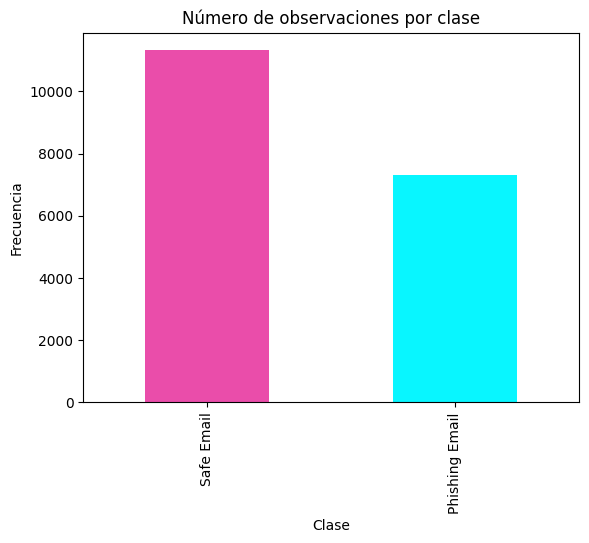

In [ ]:
import matplotlib.pyplot as plt

df["Email Type"].value_counts().plot(
    kind="bar",
    color=["#ea4daa", "#08f6ff"]   # ← lista, no string
)

plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.title("Número de observaciones por clase")
plt.show()

# Preparación

In [ ]:
texts = df["Email Text"].astype(str).values
labels = df["Email Type"].values

In [ ]:
import pandas as pd
# 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels,
    test_size=0.3,
    random_state=1234,
    stratify=labels
)

# 30% test
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test,
    test_size=0.5,
    random_state=1234,
    stratify=y_test
)
print(len(y_train), len(y_val), len(y_test))


13055 2797 2798


In [ ]:
import numpy as np

def counts(arr):
    vals, cnts = np.unique(arr, return_counts=True)
    return dict(zip(vals, cnts))

print("TRAIN:", counts(y_train))
print("VAL:  ", counts(y_val))
print("TEST: ", counts(y_test))


TRAIN: {'Phishing Email': np.int64(5130), 'Safe Email': np.int64(7925)}
VAL:   {'Phishing Email': np.int64(1099), 'Safe Email': np.int64(1698)}
TEST:  {'Phishing Email': np.int64(1099), 'Safe Email': np.int64(1699)}


Palabras únicas por corpus

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tok = Tokenizer()
tok.fit_on_texts(texts)

len(tok.word_index)

166603

In [ ]:
from collections import Counter

# Usar tu vocab_size actual
vocab_size = 30000

# Tokenizador
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)  # texts = tu lista de emails

# Convertir textos a secuencias
sequences = tokenizer.texts_to_sequences(texts)

# Contar tokens <OOV>
oov_count = sum(seq.count(tokenizer.word_index["<OOV>"]) for seq in sequences)
total_tokens = sum(len(seq) for seq in sequences)
oov_ratio = oov_count / total_tokens

print(f"Total tokens: {total_tokens}")
print(f"Tokens fuera del vocabulario (<OOV>): {oov_count}")
print(f"Proporción de tokens OOV: {oov_ratio:.4%}")

Total tokens: 7892187
Tokens fuera del vocabulario (<OOV>): 357272
Proporción de tokens OOV: 4.5269%


5.26% de tokens fuera del vocabulario.

Eso significa que 1 de cada 20 palabras que el modelo ve no está en el vocabulario.

Elección de padding,según la longitud de los textos

In [ ]:
import numpy as np #729

lengths = np.array([len(t.split()) for t in texts])
np.percentile(lengths, [50, 75, 90, 95, 99])

array([ 159.  ,  354.  ,  729.  , 1220.  , 2787.53])

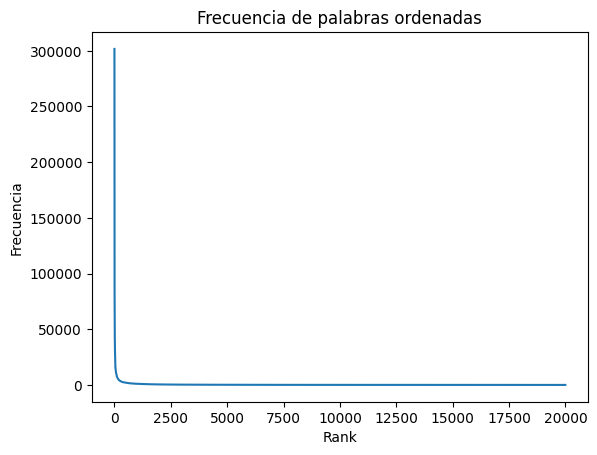

In [ ]:
import matplotlib.pyplot as plt

freqs = list(tok.word_counts.values())
freqs.sort(reverse=True)

plt.plot(freqs[:20000])
plt.title("Frecuencia de palabras ordenadas")
plt.xlabel("Rank")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
#from tensorflow.keras.preprocessing.text import Tokenizer
#from tensorflow.keras.preprocessing.sequence import pad_sequences
#i#mport numpy as np

# Elegimos vocabulario
#vocab_size = 30000
#max_length = 729  # padding

#tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
#tokenizer.fit_on_texts(X_train)

# Secuencias
#X_train_seq = tokenizer.texts_to_sequences(X_train)
#X_val_seq   = tokenizer.texts_to_sequences(X_val)
#X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Padding
#X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
#X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_length, padding='post')
#X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_length, padding='post')



In [ ]:
print(X_test.shape)

(2798,)


In [ ]:
# ============================================
#   PREPROCESAMIENTO UNIFICADO PARA TODAS LAS REDES
# ============================================

import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# STOPWORDS inglés + español
stop_en = set(stopwords.words('english'))
stop_es = set(stopwords.words('spanish'))
all_stops = stop_en.union(stop_es)

# --- Limpieza ---
def clean_text(t):
    t = t.lower()
    t = re.sub(r"[^a-zA-Z0-9áéíóúñü ]", " ", t)
    words = t.split()
    words = [w for w in words if w not in all_stops]
    return " ".join(words)

# --- LIMPIAR TEXTOS ---
X_train_clean = [clean_text(t) for t in X_train]
X_val_clean   = [clean_text(t) for t in X_val]
X_test_clean  = [clean_text(t) for t in X_test]

# ---------------------------------------------
#
# ---------------------------------------------
vocab_size  = 30000
max_length  = 729   # tu padding original

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>",
    lower=True,
    filters=""   # porque ya limpiamos nosotros
)

tokenizer.fit_on_texts(X_train_clean)

# --- SECUENCIAS ---
X_train_seq = tokenizer.texts_to_sequences(X_train_clean)
X_val_seq   = tokenizer.texts_to_sequences(X_val_clean)
X_test_seq  = tokenizer.texts_to_sequences(X_test_clean)

# --- PADDING ---
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_length, padding='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_length, padding='post')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
print(X_test.shape)

(2798,)


Etiquetas

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Ajustar + transformar
y_train_int = le.fit_transform(y_train)
y_val_int   = le.transform(y_val)
y_test_int  = le.transform(y_test)

print(y_train_int[:10])

num_classes = 2

y_train_cat = to_categorical(y_train_int, num_classes=num_classes)
y_val_cat   = to_categorical(y_val_int, num_classes=num_classes)
y_test_cat  = to_categorical(y_test_int, num_classes=num_classes)

[1 1 1 0 1 0 1 1 0 0]


In [ ]:
print(y_train_int[:10])
print(y_train_cat[:3])

[1 1 1 0 1 0 1 1 0 0]
[[0. 1.]
 [0. 1.]
 [0. 1.]]


Esta función para obtener las métricas

In [ ]:
from sklearn.metrics import precision_score, accuracy_score
import numpy as np

def evaluate_model(model, X_test_pad, y_test_cat, label=""):
    # Predicciones del modelo
    y_pred_prob = model.predict(X_test_pad)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test_cat, axis=1)

    # Métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)

    print(f"{label} → Accuracy: {acc:.4f} | Precision: {prec:.4f}")

    return acc, prec


Para el cálculo de precision

In [ ]:

def calculate_precision(model, X, y_true_cat):
    # Predecir probabilidades
    y_pred_prob = model.predict(X)

    # Convertir a etiquetas
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_true_cat, axis=1)

    # Calcular precision
    precision = precision_score(y_true, y_pred)
    return precision

Etiquetas

In [ ]:
le = LabelEncoder()

# Convertir etiquetas a enteros
y_train_enc = le.fit_transform(y_train)  # ejemplo: 'Safe Email' -> 0, 'Phishing Email' -> 1
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

# RNN

#Arquitectura

In [ ]:
max_words = 30000
maxlen = 729

from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

def build_model(lr):
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=64, input_length=maxlen),
        LSTM(64, return_sequences=True),
        LSTM(64, return_sequences=True),
        LSTM(64, return_sequences=False),
        Dense(64, activation='relu'),
        Dense(2, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy',  tf.keras.metrics.Recall(),tf.keras.metrics.Precision()]
    )

    return model

# Entrenamiento

In [ ]:
model_lr_1   = build_model(0.001)
model_lr_2  = build_model(0.0001)
model_lr_3 = build_model(0.00001)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
history_lr_1 = model_lr_1.fit(
    X_train_pad, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_pad, y_val_cat),
    callbacks=[early_stop],
)

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 36s 71ms/step - accuracy: 0.6026 - loss: 0.6749 - precision: 0.6026 - recall: 0.6026 - val_accuracy: 0.6174 - val_loss: 0.6647 - val_precision: 0.6174 - val_recall: 0.6174
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 29s 70ms/step - accuracy: 0.6191 - loss: 0.6650 - precision: 0.6191 - recall: 0.6191 - val_accuracy: 0.6182 - val_loss: 0.6616 - val_precision: 0.6182 - val_recall: 0.6182
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 29s 70ms/step - accuracy: 0.6287 - loss: 0.6548 - precision: 0.6287 - recall: 0.6287 - val_accuracy: 0.6117 - val_loss: 0.6691 - val_precision: 0.6117 - val_recall: 0.6117
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 29s 70ms/step - accuracy: 0.6170 - loss: 0.6562 - precision: 0.6170 - recall: 0.6170 - val_accuracy: 0.6196 - val_loss: 0.6661 - val_precision: 0.6196 - val_recall: 0.6196
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.6176 - loss: 0.6480 - precision: 0.6176 - recall: 0.6176 - val_accuracy: 0.6189 - va

In [ ]:
history_lr_2 = model_lr_2.fit(
    X_train_pad, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_pad, y_val_cat),
    callbacks=[early_stop]
)

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.6052 - loss: 0.6758 - precision_1: 0.6052 - recall_1: 0.6052 - val_accuracy: 0.6071 - val_loss: 0.6704 - val_precision_1: 0.6071 - val_recall_1: 0.6071
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - accuracy: 0.6034 - loss: 0.6722 - precision_1: 0.6034 - recall_1: 0.6034 - val_accuracy: 0.6110 - val_loss: 0.6683 - val_precision_1: 0.6110 - val_recall_1: 0.6110
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 28s 69ms/step - accuracy: 0.6179 - loss: 0.6664 - precision_1: 0.6179 - recall_1: 0.6179 - val_accuracy: 0.6221 - val_loss: 0.6591 - val_precision_1: 0.6221 - val_recall_1: 0.6221
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 28s 69ms/step - accuracy: 0.6299 - loss: 0.6547 - precision_1: 0.6299 - recall_1: 0.6299 - val_accuracy: 0.6332 - val_loss: 0.6459 - val_precision_1: 0.6332 - val_recall_1: 0.6332
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - accuracy: 0.6557 - loss: 0.6327 - precision_1: 0.6557 - recall_1

In [ ]:
history_lr_3 = model_lr_3.fit(
    X_train_pad, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_pad, y_val_cat),
    callbacks=[early_stop],
)

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 32s 71ms/step - accuracy: 0.6003 - loss: 0.6851 - precision_2: 0.6003 - recall_2: 0.6003 - val_accuracy: 0.6071 - val_loss: 0.6696 - val_precision_2: 0.6071 - val_recall_2: 0.6071
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 29s 70ms/step - accuracy: 0.6067 - loss: 0.6711 - precision_2: 0.6067 - recall_2: 0.6067 - val_accuracy: 0.6071 - val_loss: 0.6696 - val_precision_2: 0.6071 - val_recall_2: 0.6071
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 28s 69ms/step - accuracy: 0.6097 - loss: 0.6692 - precision_2: 0.6097 - recall_2: 0.6097 - val_accuracy: 0.6071 - val_loss: 0.6695 - val_precision_2: 0.6071 - val_recall_2: 0.6071
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 44s 76ms/step - accuracy: 0.6047 - loss: 0.6718 - precision_2: 0.6047 - recall_2: 0.6047 - val_accuracy: 0.6071 - val_loss: 0.6695 - val_precision_2: 0.6071 - val_recall_2: 0.6071
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 28s 69ms/step - accuracy: 0.6015 - loss: 0.6731 - precision_2: 0.6015 - recall_2

# Comparar entre modelos

In [ ]:
acc1, prec1 = evaluate_model(model_lr_1,   X_test_pad, y_test_cat, "LR=0.001")
acc2, prec2 = evaluate_model(model_lr_2,  X_test_pad, y_test_cat, "LR=0.0001")
acc3, prec3 = evaluate_model(model_lr_3, X_test_pad, y_test_cat, "LR=0.00001")

88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step
LR=0.001 → Accuracy: 0.6212 | Precision: 0.6159
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step
LR=0.0001 → Accuracy: 0.6848 | Precision: 0.6628
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step
LR=0.00001 → Accuracy: 0.6072 | Precision: 0.6072


In [ ]:
results = {
    "0.001": (acc1, prec1),
    "0.0001": (acc2, prec2),
    "0.00001": (acc3, prec3)
}

best_model = max(results, key=lambda x: results[x][0])


# --- Mostrar los resultados de los 3 modelos ---
print("Resultados de todos los modelos:\n")
for lr, (acc, prec) in results.items():
    print(f"LR={lr} → Accuracy={acc:.4f} | Precision={prec:.4f}")

Resultados de todos los modelos:

LR=0.001 → Accuracy=0.6212 | Precision=0.6159
LR=0.0001 → Accuracy=0.6848 | Precision=0.6628
LR=0.00001 → Accuracy=0.6072 | Precision=0.6072


Gráfico del mejor

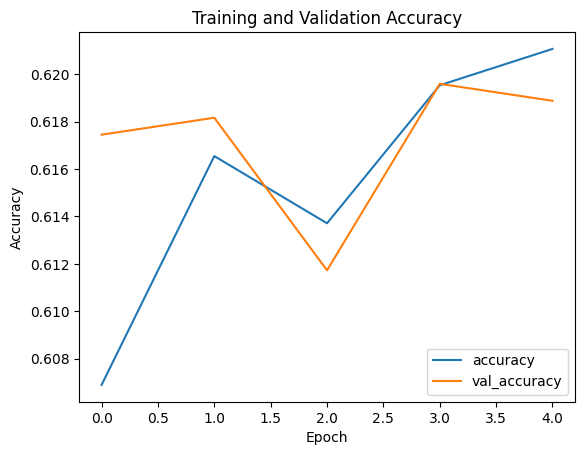

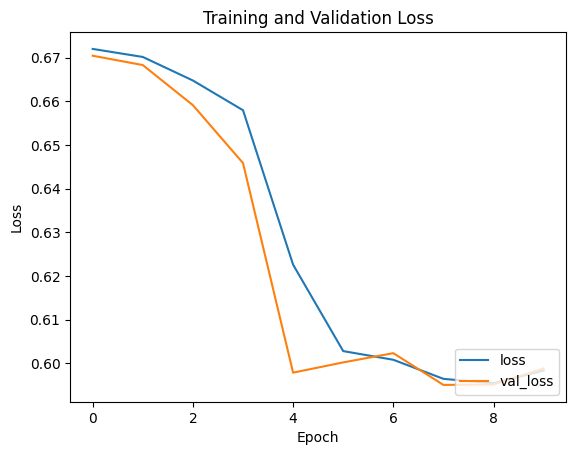

In [ ]:
plt.plot(history_lr_1.history['accuracy'], label='accuracy')
plt.plot(history_lr_1.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

#plt.plot(history_lr_2.history['precision_10'], label='precision')
#plt.plot(history_lr_2.history['val_precision_10'], label='val_precision')
#plt.xlabel('Epoch')
#plt.ylabel('Precision')
#plt.title('Training and Validation Precision')
#plt.legend()
#plt.show()


plt.plot(history_lr_2.history['loss'], label='loss')
plt.plot(history_lr_2.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='lower right')
plt.show()

In [ ]:
print(history_lr_2.history.keys())

dict_keys(['accuracy', 'loss', 'precision_1', 'recall_1', 'val_accuracy', 'val_loss', 'val_precision_1', 'val_recall_1'])


Matriz de confusión

88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


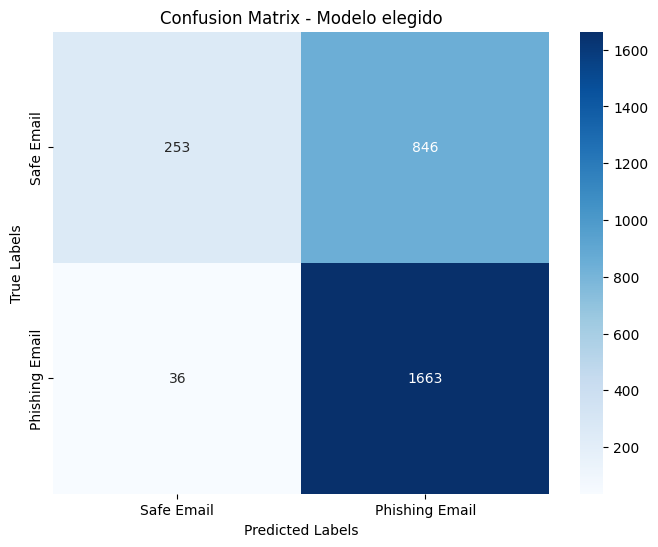

                precision    recall  f1-score   support

    Safe Email       0.88      0.23      0.36      1099
Phishing Email       0.66      0.98      0.79      1699

      accuracy                           0.68      2798
     macro avg       0.77      0.60      0.58      2798
  weighted avg       0.75      0.68      0.62      2798



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# modelo elegido
model_que_tu_quieras = model_lr_2

# Predicciones
y_pred_prob = model_que_tu_quieras.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)

# Convertir y_test de one-hot a etiquetas
y_test_labels = np.argmax(y_test_cat, axis=1)

# Nombres de clases
labels_names = ['Safe Email', 'Phishing Email']

# Matriz de confusión
cm = confusion_matrix(y_test_labels, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_names, yticklabels=labels_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Modelo elegido')
plt.show()

# Reporte de clasificación
print(classification_report(y_test_labels, y_pred, target_names=labels_names))


# CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, MaxPooling1D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def build_cnn_model(lr):
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=64, input_length=maxlen),  # embedding más grande
        Conv1D(128, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Conv1D(128, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dense(2, activation='softmax')  # binario con one-hot
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy',      tf.keras.metrics.Recall(),tf.keras.metrics.Precision()]
    )

    return model

In [ ]:
# Crear modelos con distintos LRs
cnn_model_lr_1  = build_cnn_model(0.000001)
cnn_model_lr_2 = build_cnn_model(0.000002)
cnn_model_lr_3  = build_cnn_model(0.000003)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


#Entrenamiento

In [ ]:

# Entrenar
history_cnn_1  = cnn_model_lr_1.fit(X_train_pad, y_train_cat,
                                        epochs=10, batch_size=32,
                                        validation_data=(X_val_pad, y_val_cat),
                                        callbacks=[early_stop])


Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5706 - loss: 0.8749 - precision_3: 0.5706 - recall_3: 0.5706 - val_accuracy: 0.5795 - val_loss: 0.7898 - val_precision_3: 0.5795 - val_recall_3: 0.5795
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5928 - loss: 0.8010 - precision_3: 0.5928 - recall_3: 0.5928 - val_accuracy: 0.5888 - val_loss: 0.7911 - val_precision_3: 0.5888 - val_recall_3: 0.5888
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.6161 - loss: 0.7616 - precision_3: 0.6161 - recall_3: 0.6161 - val_accuracy: 0.6021 - val_loss: 0.7606 - val_precision_3: 0.6021 - val_recall_3: 0.6021
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6347 - loss: 0.7131 - precision_3: 0.6347 - recall_3: 0.6347 - val_accuracy: 0.6153 - val_loss: 0.7365 - val_precision_3: 0.6153 - val_recall_3: 0.6153
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6465 - loss: 0.6865 - precision_3: 0.6465 - recall_3: 0.6

In [ ]:
history_cnn_2 = cnn_model_lr_2.fit(X_train_pad, y_train_cat,
                                         epochs=10, batch_size=32,
                                         validation_data=(X_val_pad, y_val_cat),
                                         callbacks=[early_stop])



Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.3973 - loss: 8.8040 - precision_4: 0.3973 - recall_4: 0.3973 - val_accuracy: 0.3929 - val_loss: 1.0611 - val_precision_4: 0.3929 - val_recall_4: 0.3929
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4022 - loss: 2.5930 - precision_4: 0.4022 - recall_4: 0.4022 - val_accuracy: 0.5188 - val_loss: 0.7914 - val_precision_4: 0.5188 - val_recall_4: 0.5188
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5645 - loss: 0.7529 - precision_4: 0.5645 - recall_4: 0.5645 - val_accuracy: 0.5935 - val_loss: 0.7227 - val_precision_4: 0.5935 - val_recall_4: 0.5935
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6178 - loss: 0.6975 - precision_4: 0.6178 - recall_4: 0.6178 - val_accuracy: 0.6082 - val_loss: 0.6977 - val_precision_4: 0.6082 - val_recall_4: 0.6082
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6463 - loss: 0.6566 - precision_4: 0.6463 - recall_4: 0.

In [ ]:
history_cnn_3  = cnn_model_lr_3.fit(X_train_pad, y_train_cat,
                                        epochs=10, batch_size=32,
                                        validation_data=(X_val_pad, y_val_cat),
                                        callbacks=[early_stop])



Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.6053 - loss: 1.2666 - precision_5: 0.6053 - recall_5: 0.6053 - val_accuracy: 0.5402 - val_loss: 0.6894 - val_precision_5: 0.5402 - val_recall_5: 0.5402
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6255 - loss: 0.7185 - precision_5: 0.6255 - recall_5: 0.6255 - val_accuracy: 0.6246 - val_loss: 0.6866 - val_precision_5: 0.6246 - val_recall_5: 0.6246
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6635 - loss: 0.6360 - precision_5: 0.6635 - recall_5: 0.6635 - val_accuracy: 0.6521 - val_loss: 0.6665 - val_precision_5: 0.6521 - val_recall_5: 0.6521
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7072 - loss: 0.5795 - precision_5: 0.7072 - recall_5: 0.7072 - val_accuracy: 0.6682 - val_loss: 0.6360 - val_precision_5: 0.6682 - val_recall_5: 0.6682
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7429 - loss: 0.5199 - precision_5: 0.7429 - recall_5: 0

Comparar entre los 3

In [ ]:
acc_001, prec_001 = evaluate_model(cnn_model_lr_1, X_test_pad, y_test_cat, "LR=0.000001")
acc_0001, prec_0001 = evaluate_model(cnn_model_lr_2, X_test_pad, y_test_cat, "LR=0.000002")
acc_003, prec_003 = evaluate_model(cnn_model_lr_3, X_test_pad, y_test_cat, "LR=0.000003")

results_cnn = {
    "0.000001": (acc_001, prec_001),
    "0.0000001": (acc_0001, prec_0001),
    "0.000003": (acc_003, prec_003)
}

88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
LR=0.000001 → Accuracy: 0.6526 | Precision: 0.7034
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
LR=0.000002 → Accuracy: 0.6798 | Precision: 0.7202
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
LR=0.000003 → Accuracy: 0.7459 | Precision: 0.7836


Gráfico del mejor de los 3

> Agregar bloque entrecomillado



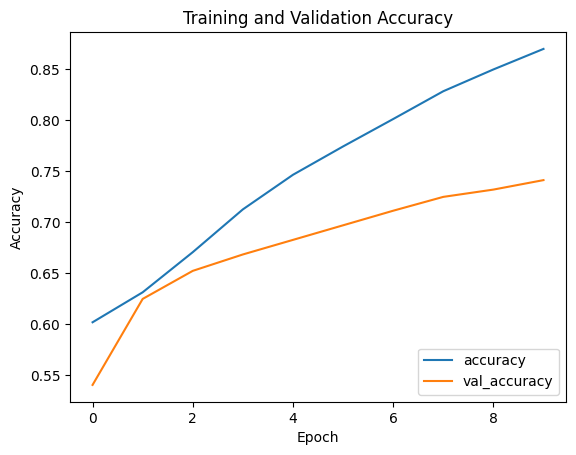

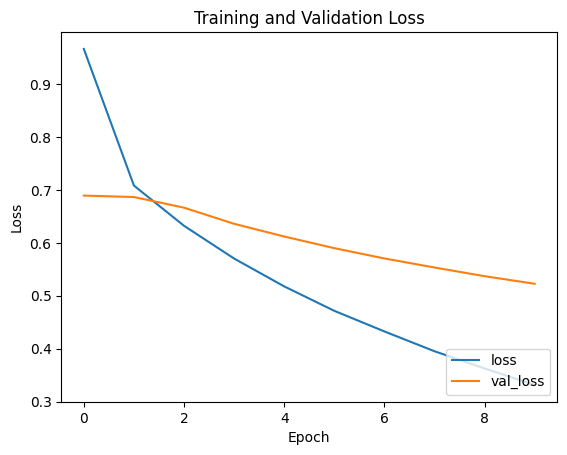

In [ ]:
plt.plot(history_cnn_3.history['accuracy'], label='accuracy')
plt.plot(history_cnn_3.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

#plt.plot(history_cnn_3.history['precision_87'], label='precision')
#plt.plot(history_cnn_3.history['val_precision_87'], label='val_precision')  # minúscula 'val_'
#plt.xlabel('Epoch')
#plt.ylabel('Precision')
#plt.title('Training and Validation Precision')
#plt.legend()
#plt.show()

plt.plot(history_cnn_3.history['loss'], label='loss')
plt.plot(history_cnn_3.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='lower right')
plt.show()

In [ ]:
print(history_cnn_3.history.keys())

dict_keys(['accuracy', 'loss', 'precision_5', 'recall_5', 'val_accuracy', 'val_loss', 'val_precision_5', 'val_recall_5'])


Matriz de confusión

88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


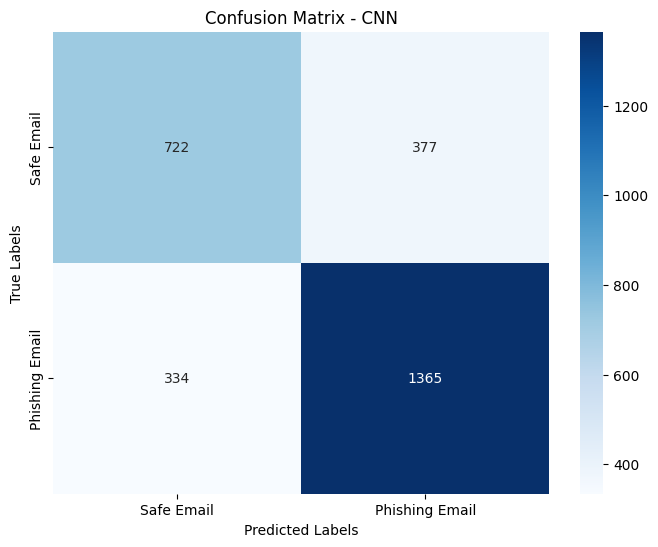

                precision    recall  f1-score   support

    Safe Email       0.68      0.66      0.67      1099
Phishing Email       0.78      0.80      0.79      1699

      accuracy                           0.75      2798
     macro avg       0.73      0.73      0.73      2798
  weighted avg       0.74      0.75      0.74      2798



In [ ]:
# Tu modelo elegido
model_que_tu_quieras = cnn_model_lr_3  # modelo Keras, no history

# Predicciones
y_pred_prob = model_que_tu_quieras.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)

# Convertir y_test de one-hot a etiquetas
y_test_labels = np.argmax(y_test_cat, axis=1)

# Nombres de clases
labels_names = ['Safe Email', 'Phishing Email']

# Matriz de confusión
cm = confusion_matrix(y_test_labels, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_names, yticklabels=labels_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - CNN')
plt.show()

# Reporte de clasificación
print(classification_report(y_test_labels, y_pred, target_names=labels_names))


# Transformers

Para precision

In [ ]:
class PrecisionCallback(tf.keras.callbacks.Callback):
    def __init__(self, training_data, validation_data):
        super().__init__()
        self.X_train, self.y_train = training_data
        self.X_val, self.y_val = validation_data
        self.train_precision_per_epoch = []
        self.val_precision_per_epoch = []

    def on_epoch_end(self, epoch, logs=None):
        # Training precision
        y_train_pred = np.argmax(self.model.predict(self.X_train, verbose=0), axis=1)
        train_prec = precision_score(self.y_train, y_train_pred)
        self.train_precision_per_epoch.append(train_prec)

        # Validation precision
        y_val_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        val_prec = precision_score(self.y_val, y_val_pred)
        self.val_precision_per_epoch.append(val_prec)

        print(f"Epoch {epoch+1}: train_precision={train_prec:.4f}, val_precision={val_prec:.4f}")

**# Prob**

In [ ]:
# ============================================
#
# ============================================

import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# STOPWORDS inglés + español
stop_en = set(stopwords.words('english'))
stop_es = set(stopwords.words('spanish'))
all_stops = stop_en.union(stop_es)

# --- Limpieza ---
def clean_text(t):
    t = t.lower()
    t = re.sub(r"[^a-zA-Z0-9áéíóúñü ]", " ", t)
    words = t.split()
    words = [w for w in words if w not in all_stops]
    return " ".join(words)

# Limpiar datasets
X_train_clean = [clean_text(t) for t in X_train]
X_val_clean   = [clean_text(t) for t in X_val]
X_test_clean  = [clean_text(t) for t in X_test]

# --- Tokenizer ---
tokenizer = Tokenizer(
    num_words=30000,
    oov_token="<OOV>",
    lower=True,
    filters=""   # IMPORTANTE: ya limpiamos nosotros
)

tokenizer.fit_on_texts(X_train_clean)

# --- Secuencias ---
X_train_seq = tokenizer.texts_to_sequences(X_train_clean)
X_val_seq   = tokenizer.texts_to_sequences(X_val_clean)
X_test_seq  = tokenizer.texts_to_sequences(X_test_clean)

# --- Padding ---
maxlen = 729
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=maxlen, padding='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=maxlen, padding='post')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


revisar

In [ ]:
#from tensorflow.keras.preprocessing.text import Tokenizer
#from tensorflow.keras.preprocessing.sequence import pad_sequences

#vocab_size = 30000
#maxlen = 729  # Número máximo de tokens por email

# Tokenizador
#tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
#tokenizer.fit_on_texts(X_train)

# Convertir a secuencias
#X_train_seq = tokenizer.texts_to_sequences(X_train)
#X_val_seq   = tokenizer.texts_to_sequences(X_val)
#X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Padding
#X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post')
#X_val_pad   = pad_sequences(X_val_seq,   maxlen=maxlen, padding='post')
#X_test_pad  = pad_sequences(X_test_seq,  maxlen=maxlen, padding='post')



In [ ]:
#from tensorflow.keras.preprocessing.text import Tokenizer

#clean_texts = tokenizer_filter(X_train, all_stops)

#tokenizer = Tokenizer(
#    num_words=30000,
#    oov_token="<OOV>",
#    lower=True,
#    filters=''
#)

#tokenizer.fit_on_texts(clean_texts)

NameError: name 'tokenizer_filter' is not defined

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Crear encoder
le = LabelEncoder()
le.fit(['Safe Email', 'Phishing Email'])

# Convertir tus etiquetas a números
y_train_enc = le.transform(y_train)  # 0 = 'Phishing Email', 1 = 'Safe Email' (depende del fit)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

# Ahora sí puedes convertir a tensores
y_train_tensor = tf.convert_to_tensor(y_train_enc, dtype=tf.int32)
y_val_tensor   = tf.convert_to_tensor(y_val_enc, dtype=tf.int32)
y_test_tensor  = tf.convert_to_tensor(y_test_enc, dtype=tf.int32)

In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
import tensorflow as tf

# Convert to numpy arrays first if they are not already
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

# 1. Initialize and fit the encoder on the training data
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

# 2. Use the fitted encoder to transform validation and test data
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

# 3. Convert the *encoded* (integer) numpy arrays to TensorFlow tensors
y_train_tensor = tf.convert_to_tensor(y_train_encoded, dtype=tf.int32)
y_val_tensor = tf.convert_to_tensor(y_val_encoded, dtype=tf.int32)
y_test_tensor = tf.convert_to_tensor(y_test_encoded, dtype=tf.int32)

# Optional: Print the classes and their new integer mapping
print("Original Classes:", le.classes_)
print("Mapped Integers:", le.transform(le.classes_))

Original Classes: ['Phishing Email' 'Safe Email']
Mapped Integers: [0 1]


# Arquitectura

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Bloque Transformer
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Embedding con posición
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim,
            mask_zero=True    )
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions


Funciones personalizadas para precision y recall

In [ ]:
def precision_m(y_true, y_pred):
    y_pred_labels = tf.argmax(y_pred, axis=1)
    y_true_labels = tf.argmax(y_true, axis=1)

    true_positives = tf.reduce_sum(
        tf.cast(y_true_labels * y_pred_labels, tf.float32)
    )
    predicted_positives = tf.reduce_sum(
        tf.cast(y_pred_labels, tf.float32)
    )
    precision = true_positives / (predicted_positives + 1e-7)
    return precision

def recall_m(y_true, y_pred):
    y_pred_labels = tf.argmax(y_pred, axis=1)
    y_true_labels = tf.argmax(y_true, axis=1)

    true_positives = tf.reduce_sum(
        tf.cast(y_true_labels * y_pred_labels, tf.float32)
    )
    possible_positives = tf.reduce_sum(
        tf.cast(y_true_labels, tf.float32)
    )
    recall = true_positives / (possible_positives + 1e-7)
    return recall

In [ ]:

class PrecisionMetric(tf.keras.metrics.Metric):
    def __init__(self, name='precision', **kwargs):
        super().__init__(name=name, **kwargs)
        self.true_positives = self.add_weight(name='tp', initializer='zeros')
        self.predicted_positives = self.add_weight(name='pp', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_labels = tf.argmax(y_pred, axis=1)
        y_true_labels = tf.argmax(y_true, axis=1)
        tp = tf.reduce_sum(tf.cast(y_true_labels * y_pred_labels, tf.float32))
        pp = tf.reduce_sum(tf.cast(y_pred_labels, tf.float32))
        self.true_positives.assign_add(tp)
        self.predicted_positives.assign_add(pp)

    def result(self):
        return self.true_positives / (self.predicted_positives + 1e-7)

class RecallMetric(tf.keras.metrics.Metric):
    def __init__(self, name='recall', **kwargs):
        super().__init__(name=name, **kwargs)
        self.true_positives = self.add_weight(name='tp', initializer='zeros')
        self.possible_positives = self.add_weight(name='pp', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_labels = tf.argmax(y_pred, axis=1)
        y_true_labels = tf.argmax(y_true, axis=1)
        tp = tf.reduce_sum(tf.cast(y_true_labels * y_pred_labels, tf.float32))
        pp = tf.reduce_sum(tf.cast(y_true_labels, tf.float32))
        self.true_positives.assign_add(tp)
        self.possible_positives.assign_add(pp)

    def result(self):
        return self.true_positives / (self.possible_positives + 1e-7)

In [ ]:
from tensorflow.keras.metrics import Precision, Recall
def build_transformer_model(lr=1e-3, maxlen=729, vocab_size=30000, embed_dim=32, num_heads=2, ff_dim=32):
    inputs = tf.keras.Input(shape=(maxlen,))
    embedding_layer = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)
    x = embedding_layer(inputs)

    mask = embedding_layer.token_emb.compute_mask(inputs)


    transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim)
    x = transformer_block(x)

    # ---------------------------------------------------
    gate = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    x = x * gate
    # ---------------------------------------------------

    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(20, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(2, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    precision_m = PrecisionMetric()
    recall_m = RecallMetric()
    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy", Precision(name="precision"), Recall(name="recall")]
    )
    return model

In [ ]:
transformer_lr_001 = build_transformer_model(lr=0.0000001)
transformer_lr_0001 = build_transformer_model(lr=0.000001)
transformer_lr_003 = build_transformer_model(lr=0.000009)


Ponderar

In [ ]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc
)
class_weights_dict = dict(enumerate(class_weights))


# Entrenamiento

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Convertir labels de texto a enteros
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

# Convertir a one-hot
y_train_cat = to_categorical(y_train_enc, num_classes=2)
y_val_cat   = to_categorical(y_val_enc, num_classes=2)
y_test_cat  = to_categorical(y_test_enc, num_classes=2)


In [ ]:
# Entrenamiento de cada modelo

history_transformer_001 = transformer_lr_001.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=10,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 37s 66ms/step - accuracy: 0.4950 - loss: 0.7428 - precision: 0.4950 - recall: 0.4950 - val_accuracy: 0.3929 - val_loss: 0.7043 - val_precision: 0.3929 - val_recall: 0.3929
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.4786 - loss: 0.7455 - precision: 0.4786 - recall: 0.4786 - val_accuracy: 0.3918 - val_loss: 0.7025 - val_precision: 0.3918 - val_recall: 0.3918
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.4883 - loss: 0.7356 - precision: 0.4883 - recall: 0.4883 - val_accuracy: 0.3940 - val_loss: 0.7011 - val_precision: 0.3940 - val_recall: 0.3940
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.4793 - loss: 0.7441 - precision: 0.4793 - recall: 0.4793 - val_accuracy: 0.3979 - val_loss: 0.7001 - val_precision: 0.3979 - val_recall: 0.3979
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.4849 - loss: 0.7411 - precision: 0.4849 - recall: 0.4849 - val_accuracy: 0.3997 - val_l

In [ ]:
history_transformer_lr_0001 = transformer_lr_0001.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=10,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - accuracy: 0.5149 - loss: 0.7066 - precision: 0.5149 - recall: 0.5149 - val_accuracy: 0.4276 - val_loss: 0.7021 - val_precision: 0.4276 - val_recall: 0.4276
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5181 - loss: 0.7064 - precision: 0.5181 - recall: 0.5181 - val_accuracy: 0.4351 - val_loss: 0.6985 - val_precision: 0.4351 - val_recall: 0.4351
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5267 - loss: 0.7022 - precision: 0.5267 - recall: 0.5267 - val_accuracy: 0.4498 - val_loss: 0.6962 - val_precision: 0.4498 - val_recall: 0.4498
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5332 - loss: 0.7005 - precision: 0.5332 - recall: 0.5332 - val_accuracy: 0.4512 - val_loss: 0.6957 - val_precision: 0.4512 - val_recall: 0.4512
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.5220 - loss: 0.6983 - precision: 0.5220 - recall: 0.5220 - val_accuracy: 0.4616 - val_lo

In [ ]:

history_transformer_003 = transformer_lr_003.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=10,
    batch_size=32,
   class_weight=class_weights_dict,

    callbacks=[early_stop]
)

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.5416 - loss: 0.6966 - precision: 0.5416 - recall: 0.5416 - val_accuracy: 0.4194 - val_loss: 0.6969 - val_precision: 0.4194 - val_recall: 0.4194
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.5194 - loss: 0.6904 - precision: 0.5194 - recall: 0.5194 - val_accuracy: 0.4784 - val_loss: 0.6906 - val_precision: 0.4785 - val_recall: 0.4784
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.5538 - loss: 0.6856 - precision: 0.5538 - recall: 0.5538 - val_accuracy: 0.5381 - val_loss: 0.6854 - val_precision: 0.5381 - val_recall: 0.5381
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5752 - loss: 0.6850 - precision: 0.5752 - recall: 0.5752 - val_accuracy: 0.6600 - val_loss: 0.6751 - val_precision: 0.6600 - val_recall: 0.6600
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.6192 - loss: 0.6782 - precision: 0.6192 - recall: 0.6192 - val_accuracy: 0.6453 - val_lo

# Evaluar

In [ ]:

def evaluate_model(model, X_test, y_test, model_name="Modelo"):
    # Predicciones
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # Si y_test viene en one-hot, convertirlo a etiquetas
    if len(y_test.shape) > 1 and y_test.shape[1] > 1:
        y_test_labels = np.argmax(y_test, axis=1)
    else:
        y_test_labels = y_test

    acc = accuracy_score(y_test_labels, y_pred)
    prec = precision_score(y_test_labels, y_pred)
    print(f"{model_name} → Accuracy: {acc:.4f} | Precision: {prec:.4f}")

    # Matriz de confusión
    labels_names = ['Safe Email', 'Phishing Email']
    cm = confusion_matrix(y_test_labels, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_names, yticklabels=labels_names)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    # Reporte de clasificación
    print(classification_report(y_test_labels, y_pred, target_names=labels_names))

    return acc, prec

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_train)  # Ajusta usando tus datos de entrenamiento

# Transformar train/val/test
y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
Transformer LR=0.001 → Accuracy: 0.4235 | Precision: 0.6514


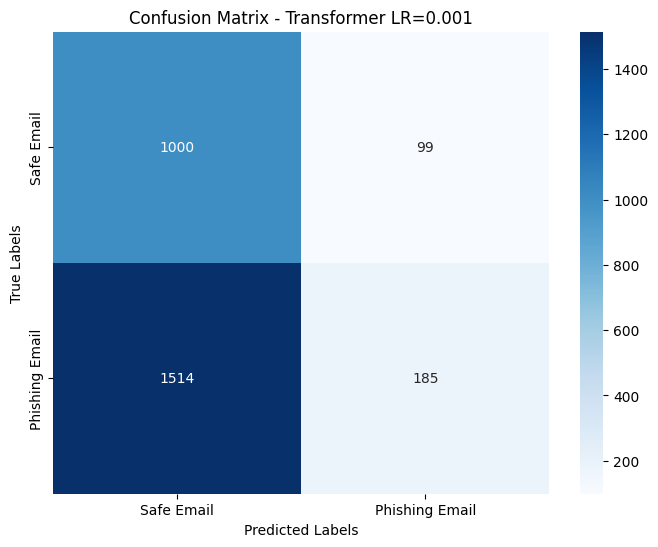

                precision    recall  f1-score   support

    Safe Email       0.40      0.91      0.55      1099
Phishing Email       0.65      0.11      0.19      1699

      accuracy                           0.42      2798
     macro avg       0.52      0.51      0.37      2798
  weighted avg       0.55      0.42      0.33      2798

88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
Transformer LR=0.0001 → Accuracy: 0.4882 | Precision: 0.7290


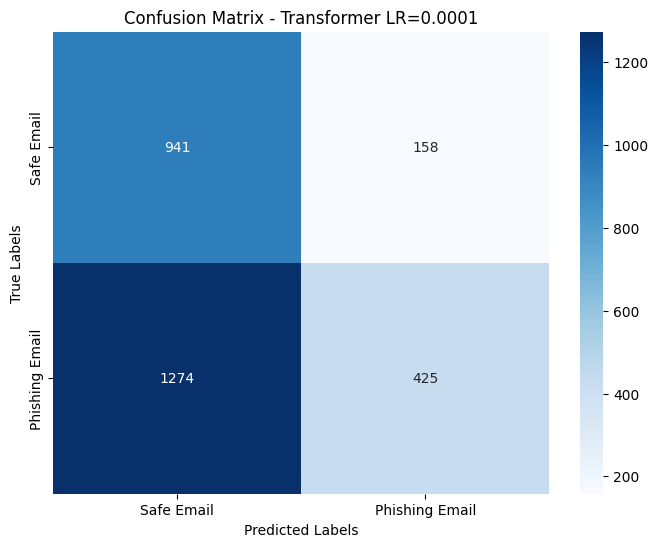

                precision    recall  f1-score   support

    Safe Email       0.42      0.86      0.57      1099
Phishing Email       0.73      0.25      0.37      1699

      accuracy                           0.49      2798
     macro avg       0.58      0.55      0.47      2798
  weighted avg       0.61      0.49      0.45      2798

88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
Transformer LR=0.003 → Accuracy: 0.8360 | Precision: 0.9288


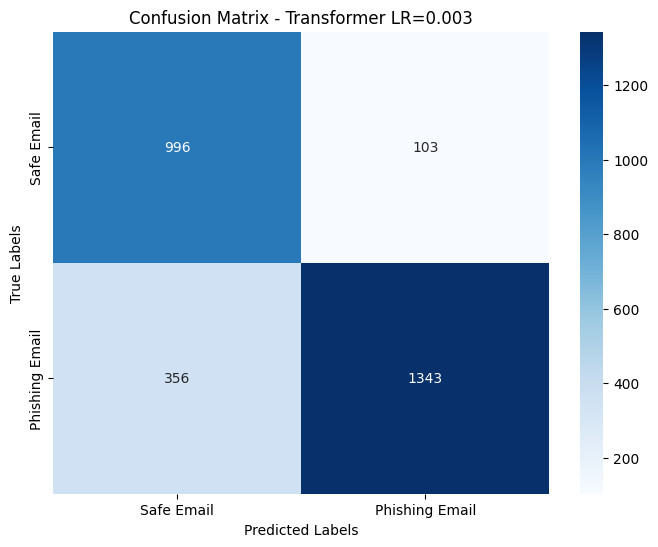

                precision    recall  f1-score   support

    Safe Email       0.74      0.91      0.81      1099
Phishing Email       0.93      0.79      0.85      1699

      accuracy                           0.84      2798
     macro avg       0.83      0.85      0.83      2798
  weighted avg       0.85      0.84      0.84      2798



In [ ]:
import seaborn as sns
acc_001, prec_001 = evaluate_model(transformer_lr_001, X_test_pad, y_test_enc, "Transformer LR=0.001")
acc_0001, prec_0001 = evaluate_model(transformer_lr_0001, X_test_pad, y_test_enc, "Transformer LR=0.0001")
acc_003, prec_003 = evaluate_model(transformer_lr_003  , X_test_pad, y_test_enc, "Transformer LR=0.003")


# Gráficos

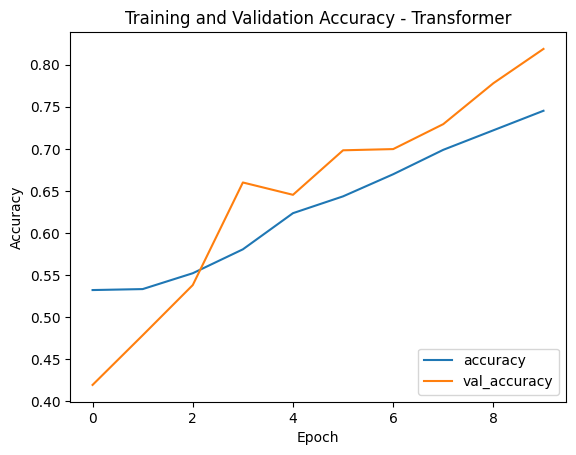

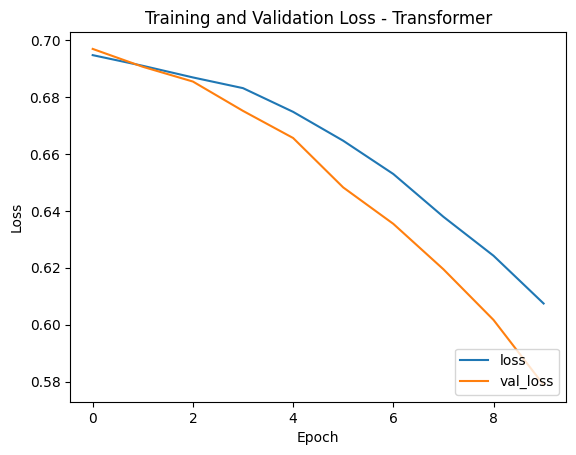

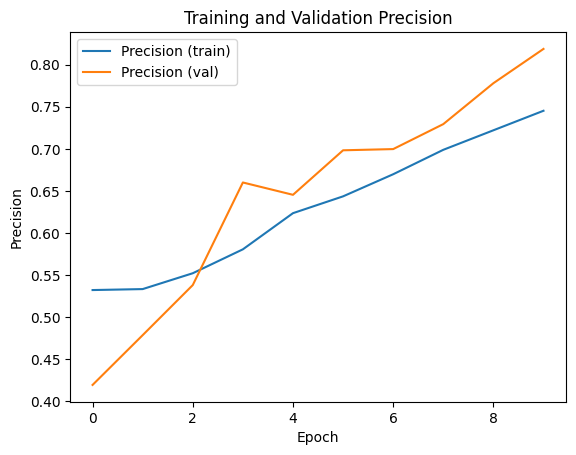

In [ ]:
import matplotlib.pyplot as plt

# Accuracy y Loss
plt.plot(history_transformer_003.history['accuracy'], label='accuracy')
plt.plot(history_transformer_003.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy - Transformer')
plt.legend(loc='lower right')
plt.show()

plt.plot(history_transformer_003.history['loss'], label='loss')
plt.plot(history_transformer_003.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss - Transformer')
plt.legend(loc='lower right')
plt.show()

plt.plot(history_transformer_003.history['precision'], label='Precision (train)')
plt.plot(history_transformer_003.history['val_precision'], label='Precision (val)')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.title('Training and Validation Precision')
plt.legend()
plt.show()


# Lime

*   List item
*   List item



In [ ]:
!pip install LIME
from lime.lime_text import LimeTextExplainer
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from IPython.display import display

# ==========================================
# FUNCIÓN DE PREDICCIÓN — LIMPIEZA
# ==========================================
def predict_proba(texts):
    cleaned = [clean_text(t) for t in texts]
    seqs = tokenizer.texts_to_sequences(cleaned)
    pads = pad_sequences(seqs, maxlen=729, padding='post')
    preds = transformer_lr_003.predict(pads, verbose=0)
    return preds

# ==========================================
# INICIALIZAR LIME
# ==========================================
explainer = LimeTextExplainer(class_names=["Phishing Email", "Safe Email"])

# ==========================================
# SELECCIONAR CORRECTAMENTE CLASIFICADOS
# ==========================================
y_pred_prob = transformer_lr_003.predict(X_test_pad, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# ✔ Umbral de confianza
confidence_threshold = 0.70

# ✔ índices correctamente clasificados Y con confianza > 0.70
correct_confident_idx = np.where(
    (y_pred == y_test_enc) &
    (np.max(y_pred_prob, axis=1) >= confidence_threshold)
)[0]

# ==========================================
# SEPARAR SAFE Y PHISHING
# ==========================================
safe_idx = [i for i in correct_confident_idx if y_test_enc[i] == 1]
phish_idx = [i for i in correct_confident_idx if y_test_enc[i] == 0]

# Tomar 3 de cada uno (si existen)
safe_samples = safe_idx[:3]
phish_samples = phish_idx[:3]

samples = safe_samples + phish_samples

print(f"SAFE correctos + confiables: {len(safe_idx)}, usando {len(safe_samples)}")
print(f"PHISH correctos + confiables: {len(phish_idx)}, usando {len(phish_samples)}")
print(f"TOTAL muestras analizadas: {len(samples)}")

# ==========================================
# MOSTRAR LIME
# ==========================================
for idx in samples:
    text = X_test[idx]

    exp = explainer.explain_instance(
        text_instance=text,
        classifier_fn=predict_proba,
        num_features=30,
        num_samples=8000
    )

    pred_class = y_pred[idx]
    real_class = y_test_enc[idx]
    prob = np.max(y_pred_prob[idx])

    print(f"\n===== EMAIL {idx} =====")
    print(f"Predicción: {['Phishing','Safe'][pred_class]} (prob={prob:.4f})")
    print(f"Real:       {['Phishing','Safe'][real_class]}")

    display(exp.show_in_notebook(text=True))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for LIME: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=7be1fd959c38da3a0ae7e4dbc44c6cf235397f05533060745747c7d4e2cc0d15
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built LIME
SAFE correctos + confiables: 257, usando 3
PHISH correctos + confiables: 23, usando 3
TOTAL muestras analizadas: 6

===== EMAIL 3 =====
Predicción: Safe (prob=0.7061)
Real:       Safe


None


===== EMAIL 15 =====
Predicción: Safe (prob=0.7052)
Real:       Safe


None


===== EMAIL 16 =====
Predicción: Safe (prob=0.7085)
Real:       Safe


...

None


===== EMAIL 212 =====
Predicción: Phishing (prob=0.8860)
Real:       Phishing


None


===== EMAIL 294 =====
Predicción: Phishing (prob=0.7670)
Real:       Phishing


None